# PyTorch Exercises: From Basics to Custom Backprop

**TIFR PreSchool 2026 — ML School**

This notebook is a graded set of exercises. Each section introduces a concept and then asks you to fill in the empty solution cell that follows.

**How to use this notebook**
- Run the *setup* cell first.
- Read the prompt, then write your answer in the cell marked `# Your code here`.
- Some exercises include `assert` statements — your solution is (probably) correct when they pass silently.
- If you get stuck, look up the relevant function in the [PyTorch docs](https://pytorch.org/docs/stable/index.html).

**Outline**

1. Tensors and basic operations
2. Broadcasting, indexing, reshaping
3. Autograd — automatic differentiation
4. Building models with `nn.Module`
5. Datasets, `DataLoader`, and a training loop
6. Custom loss functions
7. Custom optimizers (writing your own SGD, Momentum, RMSProp, Adam)
8. Custom autograd functions (forward + backward by hand)
9. Hooks, gradient surgery, higher-order gradients
10. Putting it all together: a tiny end-to-end project

## Setup

Run this cell once at the start of the session.

In [28]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt

torch.manual_seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Device:', device)

PyTorch version: 2.11.0+cpu
Device: cpu


---
## 1. Tensors and basic operations

A `torch.Tensor` is a multi-dimensional array with a `dtype`, a `device`, and (optionally) a `requires_grad` flag.

Useful constructors:
- `torch.tensor(data)` — from a Python list / NumPy array
- `torch.zeros`, `torch.ones`, `torch.eye`, `torch.arange`, `torch.linspace`
- `torch.randn`, `torch.rand`, `torch.randint`
- `.to(device)`, `.float()`, `.long()` for conversions

### Exercise 1.1 — Build a few tensors

Create the following tensors:

1. `a` — a `float32` tensor of shape `(3, 4)` filled with zeros.
2. `b` — the 5×5 identity matrix.
3. `c` — a tensor containing the integers 0, 2, 4, ..., 18 (i.e. even numbers from 0 up to 18 inclusive).
4. `d` — a `(2, 3, 4)` tensor of standard-normal random numbers.

Print each tensor's `shape` and `dtype`.

In [ ]:
a = torch.zeros((3, 4), dtype=torch.float32)

b = torch.eye(5)

c = torch.arange(0, 20, 2)

d = torch.randn((2, 3, 4))

for name, tensor in [("a", a), ("b", b), ("c", c), ("d", d)]:
    print(f"{name}: ")
    print(f"shape: {tensor.shape}")
    print(f"dtype: {tensor.dtype}\n")
    print("-" * 40)

a: 
shape: torch.Size([3, 4])
dtype: torch.float32

----------------------------------------
b: 
shape: torch.Size([5, 5])
dtype: torch.float32

----------------------------------------
c: 
shape: torch.Size([10])
dtype: torch.int64

----------------------------------------
d: 
shape: torch.Size([2, 3, 4])
dtype: torch.float32

----------------------------------------


### Exercise 1.2 — Element-wise math vs. matrix math

Given two random matrices `X` of shape `(4, 3)` and `Y` of shape `(3, 5)`:

1. Compute their **matrix product** `Z` of shape `(4, 5)` two different ways: with `@` and with `torch.matmul`.
2. Compute the element-wise product of `X` with itself.
3. Compute the sum of all elements of `Z`, the column-wise mean (one value per column), and the row-wise max.

Verify the two matrix-product results agree using `torch.allclose`.

In [ ]:
X = torch.randn(4, 3)
Y = torch.randn(3, 5)

Z1 = X @ Y
Z2 = torch.matmul(X, Y)

print("Z1 =\n", Z1)
print("\nZ2 =\n", Z2)

print("\nAre Z1 and Z2 equal?")
print(torch.allclose(Z1, Z2))


X_squared = X * X

print("\nElement-wise product X * X =\n", X_squared)


total_sum = Z1.sum()

column_mean = Z1.mean(dim=0)  

row_max = Z1.max(dim=1).values

print("\nSum of all elements in Z:")
print(total_sum)

print("\nColumn-wise mean:")
print(column_mean)

print("\nRow-wise max:")
print(row_max)

Z1 =
 tensor([[-0.8630, -0.6959,  1.3115, -3.4914,  0.8080],
        [-0.0325, -0.5580, -1.1872,  0.2457,  0.9017],
        [-0.9312, -0.1733,  1.1320, -2.7567, -0.0036],
        [ 0.2542, -0.5634, -0.0778, -0.2565,  0.9297]])

Z2 =
 tensor([[-0.8630, -0.6959,  1.3115, -3.4914,  0.8080],
        [-0.0325, -0.5580, -1.1872,  0.2457,  0.9017],
        [-0.9312, -0.1733,  1.1320, -2.7567, -0.0036],
        [ 0.2542, -0.5634, -0.0778, -0.2565,  0.9297]])

Are Z1 and Z2 equal?
True

Element-wise product X * X =
 tensor([[1.9561, 2.4649, 1.5166],
        [1.9450, 1.3715, 0.1879],
        [3.0076, 1.7850, 0.7869],
        [0.5898, 0.0033, 0.0502]])

Sum of all elements in Z:
tensor(-6.0075)

Column-wise mean:
tensor([-0.3931, -0.4976,  0.2946, -1.5647,  0.6590])

Row-wise max:
tensor([1.3115, 0.9017, 1.1320, 0.9297])


---
## 2. Broadcasting, indexing, reshaping

Broadcasting lets you operate on tensors of different shapes without writing loops, as long as their trailing dimensions are *compatible* (equal, or one of them is 1).

### Exercise 2.1 — Standardise the columns of a matrix

Given a matrix `M` of shape `(N, D)`, write code that produces `M_std` where each column has mean 0 and standard deviation 1. **Use broadcasting — no explicit loops.**

After your code, the asserts below should pass.

In [8]:
M = torch.randn(100, 5) * torch.tensor([1., 2., 3., 4., 5.]) + torch.tensor([10., -3., 0., 7., 1.])

# Your code here: produce M_std
M_std = (M - M.mean(dim=0)) / M.std(dim=0, unbiased=False)

assert torch.allclose(M_std.mean(dim=0), torch.zeros(5), atol=1e-5)
assert torch.allclose(M_std.std(dim=0, unbiased=False), torch.ones(5), atol=1e-5)
print('OK')

OK


### Exercise 2.2 — Reshape and permute

Start from `T = torch.arange(24)`.

1. Reshape `T` to shape `(2, 3, 4)` and call it `T1`.
2. Permute `T1`'s axes so the result has shape `(4, 2, 3)`. Call it `T2`.
3. Flatten `T2` back to a 1-D tensor `T3`.
4. Is `T3` equal to `T`? Why or why not?

In [ ]:
T = torch.arange(24)

T1 = T.reshape(2, 3, 4)

T2 = T1.permute(2, 0, 1)

T3 = T2.reshape(-1)

print("T1 shape:", T1.shape)
print("T2 shape:", T2.shape)
print("T3 shape:", T3.shape)

print("\nT3 =")
print(T3)

print("\nIs T3 equal to T?")
print(torch.equal(T3, T))
print("\nT3 is not equal to T because permute() changes the order of axes, which changes how elements are arranged in memory. \nWhen flattened afterward, the elements come out in a different order than the original tensor.")

T1 shape: torch.Size([2, 3, 4])
T2 shape: torch.Size([4, 2, 3])
T3 shape: torch.Size([24])

T3 =
tensor([ 0,  4,  8, 12, 16, 20,  1,  5,  9, 13, 17, 21,  2,  6, 10, 14, 18, 22,
         3,  7, 11, 15, 19, 23])

Is T3 equal to T?
False

T3 is not equal to T because permute() changes the order of axes, which changes how elements are arranged in memory. 
When flattened afterward, the elements come out in a different order than the original tensor.


### Exercise 2.3 — Boolean / fancy indexing

Given `x = torch.randn(1000)`:

1. Build a mask that selects the entries of `x` strictly greater than 1.
2. Replace those entries (in a copy `y`) with the value `1.0`. The original `x` should be untouched.
3. Report the fraction of entries that were clipped.

In [19]:

x = torch.randn(1000)
mask = x > 1

y = x.clone()
y[mask] = 1.0

fraction_clipped = mask.float().mean()

print("Number of clipped entries:", mask.sum().item())
print("Fraction clipped:", fraction_clipped.item())

print("\nOriginal x unchanged?")
print(torch.any(x > 1).item())

Number of clipped entries: 151
Fraction clipped: 0.1509999930858612

Original x unchanged?
True


---
## 3. Autograd

PyTorch's `autograd` engine records operations on tensors that have `requires_grad=True` into a dynamic computation graph, then computes gradients on demand via `.backward()`.

Key ideas:
- Only **leaf** tensors with `requires_grad=True` accumulate gradients in `.grad`.
- `.backward()` traverses the graph in reverse, multiplying Jacobian-vector products.
- Call `tensor.detach()` to break a tensor out of the graph; wrap code in `torch.no_grad()` to disable tracking entirely.

### Exercise 3.1 — Gradient of a scalar function by hand and by autograd

Let $f(x) = 3x^3 - 5x^2 + 2x - 7$. Analytically, $f'(x) = 9x^2 - 10x + 2$.

1. Create `x = torch.tensor(2.0, requires_grad=True)`.
2. Compute `y = f(x)`, then `y.backward()`.
3. Check that `x.grad` equals $9 \cdot 2^2 - 10 \cdot 2 + 2 = 18$.

In [18]:

x = torch.tensor(2.0, requires_grad=True)

y = 3*x**3 - 5*x**2 + 2*x - 7

y.backward()

# 3. Print gradient
print("Autograd gradient:", x.grad.item())

expected = 9*(2**2) - 10*2 + 2
print("Expected gradient:", expected)

Autograd gradient: 18.0
Expected gradient: 18


### Exercise 3.2 — Gradient of a vector-valued function

Let $\mathbf{w} \in \mathbb{R}^3$ and $\mathbf{x} \in \mathbb{R}^3$, and define
$$L = \tfrac{1}{2} \| \mathbf{w} \odot \mathbf{x} - \mathbf{t} \|_2^2$$
for some target `t`.

Compute `dL/dw` for the given numerical values, using autograd. Then check it against the closed-form expression $\nabla_\mathbf{w} L = (\mathbf{w}\odot\mathbf{x} - \mathbf{t}) \odot \mathbf{x}$.

In [17]:
w = torch.tensor([0.5, -1.0, 2.0], requires_grad=True)
x = torch.tensor([1.0, 2.0, -0.5])
t = torch.tensor([0.0, 0.0, 1.0])

# Your code here
y = w * x
L = 0.5 * ((y - t) ** 2).sum()

L.backward()

print("Autograd gradient:")
print(w.grad)

grad_closed = (w * x - t) * x

print("\nClosed-form gradient:")
print(grad_closed)

print("\nDo they match?")
print(torch.allclose(w.grad, grad_closed))

Autograd gradient:
tensor([ 0.5000, -4.0000,  1.0000])

Closed-form gradient:
tensor([ 0.5000, -4.0000,  1.0000], grad_fn=<MulBackward0>)

Do they match?
True


### Exercise 3.3 — `detach`, `no_grad`, and gradient accumulation

Build a small experiment that demonstrates each of these behaviours. For a parameter `p = torch.tensor(1.0, requires_grad=True)`:

1. Compute the gradient of `loss = p**2` twice in a row, **without** calling `p.grad.zero_()` in between. What is `p.grad` after the second call?
2. Repeat, but call `p.grad.zero_()` between the two backward passes.
3. Show that `(p.detach() ** 2).backward()` fails (or produces no gradient).
4. Show that operations inside `with torch.no_grad():` produce tensors with `requires_grad=False`.

In [20]:
p = torch.tensor(1.0, requires_grad=True)

# 1.

loss = p**2
loss.backward()

print("After first backward:")
print(p.grad) 

loss = p**2
loss.backward()

print("\nAfter second backward (without zero_grad):")
print(p.grad)   

# 2.
p.grad.zero_()

loss = p**2
loss.backward()

print("\nAfter backward after zeroing:")
print(p.grad) 

p.grad.zero_()

loss = p**2
loss.backward()

print("\nAfter second backward with zero_grad:")
print(p.grad) 


# 3. 
q = p.detach() ** 2

print("\nq.requires_grad =", q.requires_grad)

try:
    q.backward()
except RuntimeError as e:
    print("\nBackward on detached tensor failed:")
    print(e)

# 4. 
with torch.no_grad():
    r = p * 5

print("\nr =", r)
print("r.requires_grad =", r.requires_grad)

After first backward:
tensor(2.)

After second backward (without zero_grad):
tensor(4.)

After backward after zeroing:
tensor(2.)

After second backward with zero_grad:
tensor(2.)

q.requires_grad = False

Backward on detached tensor failed:
element 0 of tensors does not require grad and does not have a grad_fn

r = tensor(5.)
r.requires_grad = False


---
## 4. Building models with `nn.Module`

Anything trainable in PyTorch is conventionally a subclass of `nn.Module`. You register `nn.Parameter`s (which automatically appear in `.parameters()`) and submodules; you implement `forward(...)`.

Building blocks worth knowing:
- `nn.Linear`, `nn.Conv2d`, `nn.LayerNorm`, `nn.Embedding`
- `nn.ReLU`, `nn.GELU`, `nn.Tanh`
- `nn.Sequential`, `nn.ModuleList`, `nn.ModuleDict`

### Exercise 4.1 — An MLP from scratch (no `nn.Linear`)

Implement a 2-layer MLP **without** using `nn.Linear` — instantiate the weights and biases yourself as `nn.Parameter`s. The model should map `D_in → H → D_out` with a `tanh` non-linearity in between.

Initialise weights with Kaiming-style scaling: `W ~ N(0, 2/fan_in)`.

In [22]:
class MyMLP(nn.Module):
    def __init__(self, d_in, hidden, d_out):
        super().__init__()

        self.W1 = nn.Parameter(
            torch.randn(d_in, hidden) * math.sqrt(2.0 / d_in)
        )
        self.b1 = nn.Parameter(torch.zeros(hidden))

        self.W2 = nn.Parameter(
            torch.randn(hidden, d_out) * math.sqrt(2.0 / hidden)
        )
        self.b2 = nn.Parameter(torch.zeros(d_out))

    def forward(self, x):
        h = torch.tanh(x @ self.W1 + self.b1)

        out = h @ self.W2 + self.b2

        return out


# Smoke test
m = MyMLP(8, 16, 4)

print(m(torch.randn(5, 8)).shape) 
print(sum(p.numel() for p in m.parameters()))

torch.Size([5, 4])
212


### Exercise 4.2 — The same MLP using `nn.Sequential`

Re-implement the model above using `nn.Linear` layers wrapped in `nn.Sequential`. Confirm that the parameter count matches your hand-built version.

In [23]:
model = nn.Sequential(
    nn.Linear(8, 16),
    nn.Tanh(),
    nn.Linear(16, 4)
)

x = torch.randn(5, 8)

print(model(x).shape) 

# Parameter count
num_params = sum(p.numel() for p in model.parameters())

print("Number of parameters:", num_params)

torch.Size([5, 4])
Number of parameters: 212


### Exercise 4.3 — Parameter counting and `.state_dict()`

Write a function `count_params(model, trainable_only=True)` that returns the total number of parameters. Use it on your MLP.

Then save the model's `state_dict()` to a file and load it back into a fresh instance. Verify the outputs match on a random input.

In [24]:
# Define the MLP
model = nn.Sequential(
    nn.Linear(8, 16),
    nn.Tanh(),
    nn.Linear(16, 4)
)


def count_params(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    else:
        return sum(p.numel() for p in model.parameters())


# Count parameters
print("Trainable parameters:", count_params(model))


torch.save(model.state_dict(), "mlp_weights.pth")

print("\nModel state_dict saved.")


model2 = nn.Sequential(
    nn.Linear(8, 16),
    nn.Tanh(),
    nn.Linear(16, 4)
)

model2.load_state_dict(torch.load("mlp_weights.pth"))

print("Weights loaded into new model.")


x = torch.randn(5, 8)

y1 = model(x)
y2 = model2(x)

print("\nOutputs identical?")
print(torch.allclose(y1, y2))

Trainable parameters: 212

Model state_dict saved.
Weights loaded into new model.

Outputs identical?
True


---
## 5. Datasets, `DataLoader`, and a training loop

PyTorch separates **datasets** (random-access containers of examples) from **data loaders** (which batch, shuffle, and parallelise). The minimal training loop is:

```python
for epoch in range(num_epochs):
    for xb, yb in loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

### Exercise 5.1 — A toy regression dataset

Generate a synthetic dataset for the function $y = \sin(2\pi x) + 0.1\,\varepsilon$ with $x \in [0, 1]$ and Gaussian noise $\varepsilon$. Make 1000 training points and 200 validation points. Wrap them in `TensorDataset`s and `DataLoader`s with batch size 32.

In [25]:
torch.manual_seed(0)

n_train = 1000
x_train = torch.rand(n_train, 1)

y_train = torch.sin(2 * torch.pi * x_train) \
          + 0.1 * torch.randn_like(x_train)


n_val = 200
x_val = torch.rand(n_val, 1)

y_val = torch.sin(2 * torch.pi * x_val) \
        + 0.1 * torch.randn_like(x_val)


train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)


xb, yb = next(iter(train_loader))

print("Batch x shape:", xb.shape)
print("Batch y shape:", yb.shape)

Batch x shape: torch.Size([32, 1])
Batch y shape: torch.Size([32, 1])


### Exercise 5.2 — Train an MLP on it

Use your `MyMLP` (or the `nn.Sequential` version) with `d_in=1`, `hidden=64`, `d_out=1`. Train for, say, 200 epochs with `MSELoss` and `torch.optim.Adam(lr=1e-2)`. Log the average training and validation loss per epoch and plot them.

Epoch  20 | Train Loss: 0.13212 | Val Loss: 0.09541
Epoch  40 | Train Loss: 0.02161 | Val Loss: 0.01561
Epoch  60 | Train Loss: 0.01234 | Val Loss: 0.01097
Epoch  80 | Train Loss: 0.01395 | Val Loss: 0.01044
Epoch 100 | Train Loss: 0.01168 | Val Loss: 0.01269
Epoch 120 | Train Loss: 0.01128 | Val Loss: 0.01097
Epoch 140 | Train Loss: 0.01074 | Val Loss: 0.01162
Epoch 160 | Train Loss: 0.01123 | Val Loss: 0.01130
Epoch 180 | Train Loss: 0.01112 | Val Loss: 0.01093
Epoch 200 | Train Loss: 0.01150 | Val Loss: 0.01242


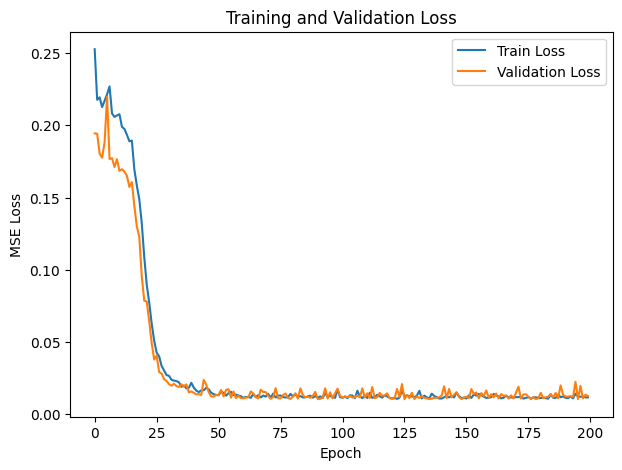

In [29]:
model = nn.Sequential(
    nn.Linear(1, 64),
    nn.Tanh(),
    nn.Linear(64, 1)
)


loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2
)


num_epochs = 200

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()

    running_train_loss = 0.0

    for xb, yb in train_loader:

        pred = model(xb)

        loss = loss_fn(pred, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)

    avg_train_loss = running_train_loss / len(train_loader.dataset)

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for xb, yb in val_loader:

            pred = model(xb)

            loss = loss_fn(pred, yb)

            running_val_loss += loss.item() * xb.size(0)

    avg_val_loss = running_val_loss / len(val_loader.dataset)

    # Save losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Train Loss: {avg_train_loss:.5f} | "
            f"Val Loss: {avg_val_loss:.5f}"
        )

plt.figure(figsize=(7,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.show()

### Exercise 5.3 — Plot the fitted curve

On a dense grid of `x` values in `[0, 1]`, predict `y_hat` (under `torch.no_grad()` and in `model.eval()` mode), and plot the predictions against the true sine and the noisy training points.

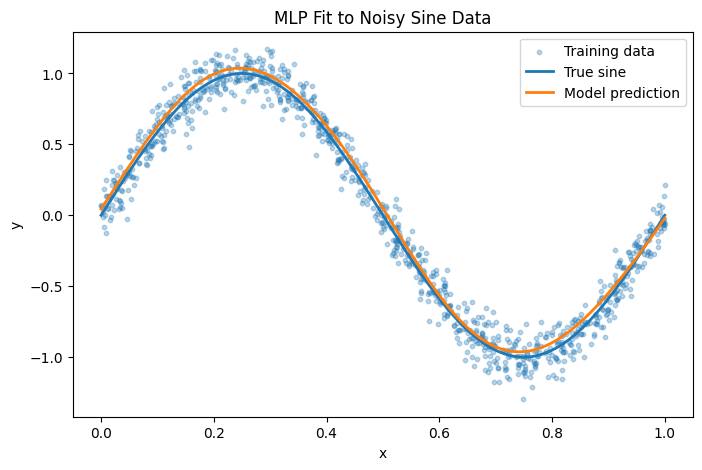

In [30]:
x_grid = torch.linspace(0, 1, 500).unsqueeze(1)

# True sine curve
y_true = torch.sin(2 * torch.pi * x_grid)


model.eval()

with torch.no_grad():
    y_hat = model(x_grid)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

plt.figure(figsize=(8, 5))

# Noisy training data
plt.scatter(
    x_train.numpy(),
    y_train.numpy(),
    s=10,
    alpha=0.3,
    label="Training data"
)

# True function
plt.plot(
    x_grid.numpy(),
    y_true.numpy(),
    linewidth=2,
    label="True sine"
)

# Model prediction
plt.plot(
    x_grid.numpy(),
    y_hat.numpy(),
    linewidth=2,
    label="Model prediction"
)

plt.xlabel("x")
plt.ylabel("y")

plt.title("MLP Fit to Noisy Sine Data")

plt.legend()

plt.show()

---
## 6. Custom loss functions

A loss function is just a differentiable function from `(prediction, target)` to a scalar. You can write it as a plain Python function or as an `nn.Module` (handy when it has learnable parameters or state).

### Exercise 6.1 — Huber loss

Implement the Huber loss
$$\ell_\delta(r) = \begin{cases} \tfrac{1}{2} r^2 & |r| \le \delta \\ \delta\,(|r| - \tfrac{1}{2}\delta) & |r| > \delta \end{cases}$$
where $r = \hat{y} - y$. Take the **mean** over the batch.

Sanity check: for very small residuals it should agree with $\tfrac{1}{2}\text{MSE}$; for very large residuals it should grow linearly. Compare against `nn.SmoothL1Loss(beta=delta)` (note the small difference: `SmoothL1` uses $r^2/(2\delta)$ on the inside, not $r^2/2$).

In [ ]:
def huber_loss(pred, target, delta=1.0):

    r = pred - target

    abs_r = torch.abs(r)

    quadratic = 0.5 * r**2

    linear = delta * (abs_r - 0.5 * delta)

    loss = torch.where(abs_r <= delta, quadratic, linear)

    # Mean over batch
    return loss.mean()

### Exercise 6.2 — Cross-entropy from scratch (numerically stable)

Implement multi-class cross-entropy from raw logits *without* calling `F.cross_entropy`, `F.log_softmax`, or `nn.LogSoftmax`.

Use the log-sum-exp trick:
$$\log\sum_j e^{z_j} = m + \log\sum_j e^{z_j - m}, \quad m = \max_j z_j$$

Verify your result against `F.cross_entropy` to within `1e-6`.

In [32]:
def cross_entropy_from_scratch(logits, targets):

    m = logits.max(dim=1, keepdim=True).values

    logsumexp = m + torch.log(
        torch.exp(logits - m).sum(dim=1, keepdim=True)
    )

    log_probs = logits - logsumexp


    nll = -log_probs[
        torch.arange(logits.shape[0]),
        targets
    ]

    return nll.mean()


torch.manual_seed(0)

logits = torch.randn(16, 5)
targets = torch.randint(0, 5, (16,))

loss_custom = cross_entropy_from_scratch(logits, targets)

loss_torch = F.cross_entropy(logits, targets)

print("Custom loss :", loss_custom.item())
print("Torch loss  :", loss_torch.item())

print("\nMatch?")
print(torch.allclose(loss_custom, loss_torch, atol=1e-6))

Custom loss : 1.891635775566101
Torch loss  : 1.891635775566101

Match?
True


---
## 7. Custom optimizers

A PyTorch optimizer is a class with a `.step()` method that, after `loss.backward()` has populated `p.grad`, updates each parameter `p` in place. We will write four optimizers from scratch.

The skeleton looks like:

```python
class MyOpt:
    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr
        self.state = {id(p): {} for p in self.params}

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue
            # update p in place

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()
```

All updates **must** happen under `torch.no_grad()` (or use `p.data` / `p.add_`) so we don't track them in the graph.

### Exercise 7.1 — Plain SGD

Implement `MySGD` with the update
$$\theta \leftarrow \theta - \eta\, g.$$

In [33]:
class MySGD:
    def __init__(self, params, lr=1e-2):
        self.params = list(params)
        self.lr = lr

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue

            # θ ← θ - η g
            p -= self.lr * p.grad

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

### Exercise 7.2 — SGD with momentum (Polyak)

Implement the heavy-ball update:
$$v \leftarrow \mu\, v + g, \qquad \theta \leftarrow \theta - \eta\, v.$$
Initialise `v` to zeros the first time you see each parameter.

In [34]:
class MyMomentum:
    def __init__(self, params, lr=1e-2, momentum=0.9):
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum

        # state dictionary for storing velocity buffers
        self.state = {id(p): {} for p in self.params}

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue

            state = self.state[id(p)]

            # Initialize velocity the first time
            if "v" not in state:
                state["v"] = torch.zeros_like(p)

            v = state["v"]

            # v ← μv + g
            v.mul_(self.momentum).add_(p.grad)

            # θ ← θ - ηv
            p.add_(-self.lr * v)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

### Exercise 7.3 — RMSProp

Implement RMSProp:
$$s \leftarrow \alpha\, s + (1-\alpha)\, g^2, \qquad \theta \leftarrow \theta - \frac{\eta}{\sqrt{s} + \epsilon}\, g.$$

In [35]:
class MyRMSProp:
    def __init__(self, params, lr=1e-3, alpha=0.99, eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.alpha = alpha
        self.eps = eps

        # state dictionary for storing running averages
        self.state = {id(p): {} for p in self.params}

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue

            g = p.grad
            state = self.state[id(p)]

            # Initialize running squared-gradient average
            if "s" not in state:
                state["s"] = torch.zeros_like(p)

            s = state["s"]

            # s ← αs + (1-α)g²
            s.mul_(self.alpha).add_((1 - self.alpha) * (g * g))

            # θ ← θ - η / (sqrt(s)+ε) * g
            p.addcdiv_(g, torch.sqrt(s) + self.eps, value=-self.lr)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

### Exercise 7.4 — Adam

Implement Adam with bias correction:
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat m_t = m_t / (1 - \beta_1^t), \quad \hat v_t = v_t / (1 - \beta_2^t)$$
$$\theta_t = \theta_{t-1} - \eta\, \hat m_t / (\sqrt{\hat v_t} + \epsilon)$$

Track the step count $t$ per parameter (it is the same for all, but you'll want it stored).

In [ ]:
class MyAdam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps


        self.state = {id(p): {} for p in self.params}

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue

            g = p.grad
            state = self.state[id(p)]

            # Initialize state on first use
            if len(state) == 0:
                state["t"] = 0
                state["m"] = torch.zeros_like(p)
                state["v"] = torch.zeros_like(p)

            m = state["m"]
            v = state["v"]

            # Increment timestep
            state["t"] += 1
            t = state["t"]

            # m_t = β1 m_{t-1} + (1-β1) g_t
            m.mul_(self.beta1).add_((1 - self.beta1) * g)

            # v_t = β2 v_{t-1} + (1-β2) g_t²
            v.mul_(self.beta2).add_((1 - self.beta2) * (g * g))

            # Bias correction
            m_hat = m / (1 - self.beta1 ** t)
            v_hat = v / (1 - self.beta2 ** t)

            # θ_t = θ_{t-1} - η m̂_t / (sqrt(v̂_t) + ε)
            p.addcdiv_(m_hat, torch.sqrt(v_hat) + self.eps, value=-self.lr)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

### Exercise 7.5 — Bake-off on the toy regression task

Train your sine-fitting MLP **four times** with identical initial weights, using `MySGD`, `MyMomentum`, `MyRMSProp`, and `MyAdam`. Plot the training-loss curve for each on the same axes. Comment on what you observe.

*Hint:* use `copy.deepcopy` on the freshly-initialised model so each optimizer starts from the same weights.

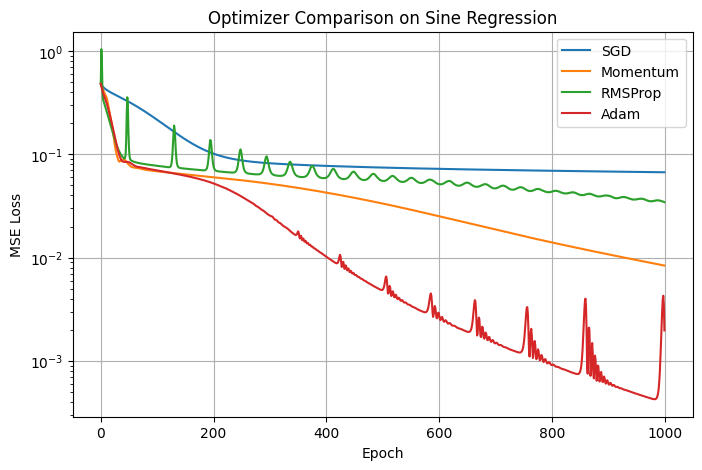

In [ ]:
import copy
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

x = torch.linspace(-2 * torch.pi, 2 * torch.pi, 500).unsqueeze(1)
y = torch.sin(x)


class SineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


base_model = SineMLP()

# Create identical copies
models = {
    "SGD": copy.deepcopy(base_model),
    "Momentum": copy.deepcopy(base_model),
    "RMSProp": copy.deepcopy(base_model),
    "Adam": copy.deepcopy(base_model),
}


optimizers = {
    "SGD": MySGD(models["SGD"].parameters(), lr=1e-2),

    "Momentum": MyMomentum(
        models["Momentum"].parameters(),
        lr=1e-2,
        momentum=0.9
    ),

    "RMSProp": MyRMSProp(
        models["RMSProp"].parameters(),
        lr=1e-3,
        alpha=0.99
    ),

    "Adam": MyAdam(
        models["Adam"].parameters(),
        lr=1e-3
    ),
}

criterion = nn.MSELoss()

num_epochs = 1000
loss_history = {name: [] for name in models}

for name in models:
    model = models[name]
    optimizer = optimizers[name]

    for epoch in range(num_epochs):

        # Forward
        pred = model(x)
        loss = criterion(pred, y)

        # Backward
        optimizer.zero_grad()
        loss.backward()

        # Update
        optimizer.step()

        loss_history[name].append(loss.item())

plt.figure(figsize=(8, 5))

for name, losses in loss_history.items():
    plt.plot(losses, label=name)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Optimizer Comparison on Sine Regression")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()

### Exercise 7.6 — Weight decay, properly

Add a `weight_decay` parameter to `MyAdam`. There are **two** common ways to apply it:

1. **L2 regularisation** — add `weight_decay * p` to the gradient *before* the moment updates.
2. **Decoupled weight decay (AdamW)** — apply `p -= lr * weight_decay * p` directly to the parameter, *separately* from the adaptive update.

Implement both as options. Discuss in a short comment why decoupled weight decay tends to behave better with Adam-family optimizers.

In [ ]:

class MyAdam:
    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=0.0,
        adamw=False,   # False -> L2 regularization, True -> AdamW
    ):
        self.params = list(params)

        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps

        self.weight_decay = weight_decay
        self.adamw = adamw

        self.state = {id(p): {} for p in self.params}

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue

            g = p.grad
            state = self.state[id(p)]

            # Initialize state
            if "m" not in state:
                state["t"] = 0
                state["m"] = torch.zeros_like(p)
                state["v"] = torch.zeros_like(p)

            m = state["m"]
            v = state["v"]

            # Step counter
            state["t"] += 1
            t = state["t"]


            # L2 regularization
            if self.weight_decay > 0 and not self.adamw:
                g = g + self.weight_decay * p

            # AdamW (decoupled)
            if self.weight_decay > 0 and self.adamw:
                p -= self.lr * self.weight_decay * p

            # m_t
            m.mul_(self.beta1).add_((1 - self.beta1) * g)

            # v_t
            v.mul_(self.beta2).add_((1 - self.beta2) * (g * g))

            # Bias correction
            m_hat = m / (1 - self.beta1 ** t)
            v_hat = v / (1 - self.beta2 ** t)

            # Parameter update
            p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

---
## 8. Custom autograd functions

Sometimes you need to define an operation whose forward or backward pass autograd doesn't already know about — e.g. a non-standard non-linearity, a discrete operation with a straight-through gradient, or a numerically tricky composite that you can simplify by hand.

The recipe is to subclass `torch.autograd.Function`:

```python
class MyFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, *inputs):
        ctx.save_for_backward(...)
        return output

    @staticmethod
    def backward(ctx, grad_output):
        (...) = ctx.saved_tensors
        return grad_inputs  # one per input to forward(), in the same order
```

Use `torch.autograd.gradcheck` (with `dtype=torch.float64`) to verify your backward is correct.

### Exercise 8.1 — `MySquare`

Warm-up. Implement `y = x**2` as a `torch.autograd.Function`. The derivative is `2x`, so the backward should return `grad_output * 2 * x`.

Verify with `gradcheck`.

In [39]:
class MySquare(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):
        # Save x for backward pass
        ctx.save_for_backward(x)

        # Forward computation
        return x ** 2

    @staticmethod
    def backward(ctx, grad_output):
        # Retrieve saved tensor
        (x,) = ctx.saved_tensors

        # dy/dx = 2x
        grad_x = grad_output * 2 * x

        return grad_x


x = torch.randn(4, dtype=torch.float64, requires_grad=True)

test = torch.autograd.gradcheck(MySquare.apply, (x,))

print("Gradcheck passed:", test)

Gradcheck passed: True


### Exercise 8.2 — `MyReLU`

Implement ReLU as a custom autograd function. The derivative is 1 for `x > 0` and 0 otherwise (the choice at `x = 0` is a sub-gradient — 0 is the conventional pick).

Then verify with `gradcheck` (perturb only at non-zero points).

In [40]:
class MyReLU(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):
        # Save input for backward
        ctx.save_for_backward(x)

        # ReLU forward
        return torch.clamp(x, min=0)

    @staticmethod
    def backward(ctx, grad_output):
        # Retrieve saved tensor
        (x,) = ctx.saved_tensors

        # Derivative: 1 for x > 0, else 0
        grad_x = grad_output * (x > 0).to(x.dtype)

        return grad_x


x = torch.randn(4, dtype=torch.float64, requires_grad=True)

x.data[x.abs() < 0.1] += 0.5

test = torch.autograd.gradcheck(MyReLU.apply, (x,))

print("Gradcheck passed:", test)

Gradcheck passed: True


### Exercise 8.3 — Numerically stable `MyLogSoftmax`

Implement log-softmax along a chosen dimension, with a hand-written backward.

Forward (use log-sum-exp for stability):
$$y_i = z_i - \log\sum_j e^{z_j}.$$

Backward — given upstream `g = ∂L/∂y`, the Jacobian of log-softmax is $I - \mathbf{1}\,\mathrm{softmax}(z)^\top$ along the chosen axis, so:
$$\frac{\partial L}{\partial z_i} = g_i - \left(\sum_j g_j\right) \cdot \mathrm{softmax}(z)_i.$$

Verify against `F.log_softmax` both forward (values) and backward (gradients) on a random input.

In [41]:
class MyLogSoftmax(torch.autograd.Function):

    @staticmethod
    def forward(ctx, z, dim):

        # Numerically stable log-sum-exp
        z_max, _ = torch.max(z, dim=dim, keepdim=True)

        shifted = z - z_max

        logsumexp = z_max + torch.log(
            torch.sum(torch.exp(shifted), dim=dim, keepdim=True)
        )

        y = z - logsumexp

        # Save tensors for backward
        softmax = torch.exp(y)

        ctx.save_for_backward(softmax)
        ctx.dim = dim

        return y

    @staticmethod
    def backward(ctx, grad_output):

        (softmax,) = ctx.saved_tensors
        dim = ctx.dim

        # sum_j g_j
        grad_sum = torch.sum(
            grad_output,
            dim=dim,
            keepdim=True
        )

        # g_i - (sum_j g_j) * softmax_i
        grad_z = grad_output - grad_sum * softmax

        return grad_z, None

torch.manual_seed(0)

z1 = torch.randn(3, 5, requires_grad=True)
z2 = z1.clone().detach().requires_grad_(True)

dim = 1

# Custom
y1 = MyLogSoftmax.apply(z1, dim)
loss1 = y1.sum()
loss1.backward()

# PyTorch reference
y2 = F.log_softmax(z2, dim=dim)
loss2 = y2.sum()
loss2.backward()

# Compare forward
print("Forward close:",
      torch.allclose(y1, y2, atol=1e-6))

# Compare gradients
print("Backward close:",
      torch.allclose(z1.grad, z2.grad, atol=1e-6))

Forward close: True
Backward close: True


### Exercise 8.4 — Straight-through estimator

Implement `MyRound` whose forward is `torch.round(x)` (non-differentiable), but whose backward acts as the identity — i.e. `grad_x = grad_output`. This is the *straight-through estimator*, commonly used to backprop through discrete operations (quantisation, hard-attention, etc.).

Test that a tiny linear layer trained with `MyRound` in the middle still learns to fit `y = 3x + 1` on a small dataset.

Final loss: 0.08968272060155869


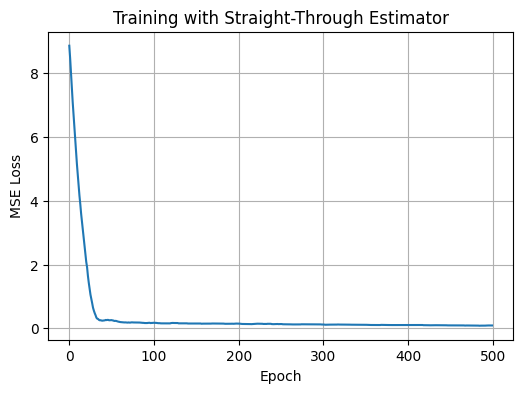

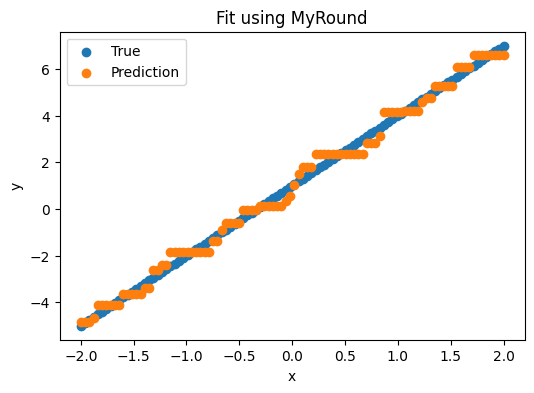

In [42]:
class MyRound(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):
        # Non-differentiable forward
        return torch.round(x)

    @staticmethod
    def backward(ctx, grad_output):
        # Straight-through estimator:
        # pretend d(round(x))/dx = 1
        return grad_output

class TinyModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.linear1 = nn.Linear(1, 8)
        self.linear2 = nn.Linear(8, 1)

    def forward(self, x):

        x = self.linear1(x)

        # Discrete operation in middle
        x = MyRound.apply(x)

        x = self.linear2(x)

        return x


torch.manual_seed(0)

x = torch.linspace(-2, 2, 100).unsqueeze(1)
y = 3 * x + 1


model = TinyModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

losses = []

for epoch in range(500):

    pred = model(x)

    loss = criterion(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())


print("Final loss:", losses[-1])

# Predictions
with torch.no_grad():
    y_pred = model(x)


plt.figure(figsize=(6,4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training with Straight-Through Estimator")

plt.grid(True)

plt.show()


plt.figure(figsize=(6,4))

plt.scatter(x.numpy(), y.numpy(), label="True")
plt.scatter(x.numpy(), y_pred.numpy(), label="Prediction")

plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.title("Fit using MyRound")

plt.show()

### Exercise 8.5 — A composite op with a custom backward: `MySwish`

Swish is $f(x) = x \cdot \sigma(x)$, where $\sigma$ is the logistic sigmoid. Its derivative is
$$f'(x) = \sigma(x) + x\,\sigma(x)\,(1 - \sigma(x)) = f(x) + \sigma(x)\,(1 - f(x)).$$

Implement it as a `torch.autograd.Function` that saves only `sigmoid(x)` from the forward (so the backward is cheaper — no recompute). Verify with `gradcheck` and compare runtime against the naïve `x * torch.sigmoid(x)` version on a large tensor.

In [43]:
import time
import torch

class MySwish(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):

        sig = torch.sigmoid(x)

        ctx.save_for_backward(sig)


        return x * sig

    @staticmethod
    def backward(ctx, grad_output):

        (sig,) = ctx.saved_tensors
        x = torch.log(sig / (1 - sig))

        grad = sig + x * sig * (1 - sig)

        return grad_output * grad


x = torch.randn(
    4,
    dtype=torch.float64,
    requires_grad=True
)

test = torch.autograd.gradcheck(
    MySwish.apply,
    (x,)
)

print("Gradcheck passed:", test)


# Large tensor
x1 = torch.randn(
    5000,
    5000,
    requires_grad=True
)

x2 = x1.clone().detach().requires_grad_(True)


start = time.time()

y1 = MySwish.apply(x1)
loss1 = y1.sum()

loss1.backward()

custom_time = time.time() - start


start = time.time()

y2 = x2 * torch.sigmoid(x2)
loss2 = y2.sum()

loss2.backward()

naive_time = time.time() - start

print(f"Custom Swish time: {custom_time:.4f} s")
print(f"Naive Swish time : {naive_time:.4f} s")

Gradcheck passed: True
Custom Swish time: 0.3855 s
Naive Swish time : 0.2220 s


---
## 9. Hooks, gradient surgery, higher-order gradients

A few more advanced tools.

### Exercise 9.1 — Register a backward hook to log gradient norms

Pick any of your `nn.Linear` layers and use `module.register_full_backward_hook(...)` to print the L2 norm of the gradient flowing through it on each backward pass. Train for a few iterations and observe.

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(1, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x


model = Net()

def grad_hook(module, grad_input, grad_output):

    # grad_output is a tuple
    grad = grad_output[0]

    norm = grad.norm().item()

    print(f"{module.__class__.__name__} grad norm: {norm:.6f}")


# Register hook on fc2
hook_handle = model.fc2.register_full_backward_hook(grad_hook)

x = torch.linspace(-2, 2, 100).unsqueeze(1)
y = 3 * x + 1

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)


for epoch in range(5):

    pred = model(x)

    loss = F.mse_loss(pred, y)

    optimizer.zero_grad()

    print(f"\nEpoch {epoch + 1}")

    loss.backward()

    optimizer.step()

    print(f"Loss: {loss.item():.6f}")


# Remove hook when done
hook_handle.remove()


Epoch 1
Linear grad norm: 0.263818
Loss: 13.221457

Epoch 2
Linear grad norm: 0.247976
Loss: 11.768952

Epoch 3
Linear grad norm: 0.239808
Loss: 10.419520

Epoch 4
Linear grad norm: 0.236575
Loss: 9.078663

Epoch 5
Linear grad norm: 0.219378
Loss: 7.762362


### Exercise 9.2 — Gradient clipping by hand

Implement global-norm gradient clipping yourself (don't call `torch.nn.utils.clip_grad_norm_`). The recipe: compute `total_norm = sqrt(sum(g.pow(2).sum() for g in grads))`; if `total_norm > max_norm`, scale every gradient by `max_norm / (total_norm + 1e-6)`.

In [45]:
def clip_grad_norm(params, max_norm):

    # Convert iterator to list
    params = list(params)

    # Compute global gradient norm
    total_norm = 0.0

    for p in params:
        if p.grad is not None:
            total_norm += p.grad.pow(2).sum()

    total_norm = torch.sqrt(total_norm)

    # Clip if needed
    if total_norm > max_norm:

        scale = max_norm / (total_norm + 1e-6)

        for p in params:
            if p.grad is not None:
                p.grad.mul_(scale)

    return total_norm

### Exercise 9.3 — Second-order gradients

For $f(x, y) = x^2 y + y^3$ at the point $(1, 2)$, compute:

1. $\partial f / \partial x$ and $\partial f / \partial y$ using `torch.autograd.grad(..., create_graph=True)`.
2. The full $2\times 2$ Hessian matrix at $(1, 2)$ by differentiating each first-order gradient again.

Check against the closed form: $\nabla f = (2xy, x^2 + 3y^2)$ and Hessian = $\begin{pmatrix} 2y & 2x \\ 2x & 6y \end{pmatrix}$, which at $(1,2)$ is $\begin{pmatrix} 4 & 2 \\ 2 & 12 \end{pmatrix}$.

In [46]:

x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)


f = x**2 * y + y**3

df_dx, df_dy = torch.autograd.grad(
    f,
    (x, y),
    create_graph=True
)

print("First-order gradients:")
print("df/dx =", df_dx.item())
print("df/dy =", df_dy.item())


d2f_dx2  = torch.autograd.grad(df_dx, x, retain_graph=True)[0]
d2f_dxdy = torch.autograd.grad(df_dx, y, retain_graph=True)[0]

d2f_dydx = torch.autograd.grad(df_dy, x, retain_graph=True)[0]
d2f_dy2  = torch.autograd.grad(df_dy, y)[0]

# Hessian matrix
H = torch.tensor([
    [d2f_dx2.item(),  d2f_dxdy.item()],
    [d2f_dydx.item(), d2f_dy2.item()]
])

print("\nHessian matrix:")
print(H)


print("\nExpected gradient: (4, 13)")
print("Expected Hessian:")
print(torch.tensor([[4., 2.],
                    [2., 12.]]))

First-order gradients:
df/dx = 4.0
df/dy = 13.0

Hessian matrix:
tensor([[ 4.,  2.],
        [ 2., 12.]])

Expected gradient: (4, 13)
Expected Hessian:
tensor([[ 4.,  2.],
        [ 2., 12.]])


---
## 10. Putting it all together

Build a small classifier on a real toy dataset using **your own** components throughout. This is open-ended — try to use as many of the pieces you wrote above as you can.

### Exercise 10 — Two-moons classification with your stack

1. Generate a `make_moons`-style dataset (you can use `sklearn.datasets.make_moons` or roll your own).
2. Build an MLP classifier (1 hidden layer of 32 units is enough). Use `MyReLU` or `MySwish` as the activation.
3. Train it with **your** `MyAdam`, using **your** `my_cross_entropy` as the loss.
4. Apply your hand-written gradient-norm clipping at every step with `max_norm=1.0`.
5. Plot the decision boundary, the training-loss curve, and final accuracy.

If everything is wired together correctly you should comfortably hit > 95% accuracy.

MyLinear grad norm = 0.0079
Epoch   0 | Loss 0.6946 | Accuracy 0.7700
MyLinear grad norm = 0.0080
MyLinear grad norm = 0.0085
MyLinear grad norm = 0.0096
MyLinear grad norm = 0.0106
MyLinear grad norm = 0.0116
MyLinear grad norm = 0.0123
MyLinear grad norm = 0.0129
MyLinear grad norm = 0.0134
MyLinear grad norm = 0.0141
MyLinear grad norm = 0.0149
MyLinear grad norm = 0.0158
MyLinear grad norm = 0.0167
MyLinear grad norm = 0.0175
MyLinear grad norm = 0.0183
MyLinear grad norm = 0.0189
MyLinear grad norm = 0.0194
MyLinear grad norm = 0.0197
MyLinear grad norm = 0.0199
MyLinear grad norm = 0.0200
MyLinear grad norm = 0.0201
Epoch  20 | Loss 0.2855 | Accuracy 0.8550
MyLinear grad norm = 0.0203
MyLinear grad norm = 0.0205
MyLinear grad norm = 0.0207
MyLinear grad norm = 0.0209
MyLinear grad norm = 0.0209
MyLinear grad norm = 0.0207
MyLinear grad norm = 0.0205
MyLinear grad norm = 0.0203
MyLinear grad norm = 0.0202
MyLinear grad norm = 0.0200
MyLinear grad norm = 0.0200
MyLinear grad norm =

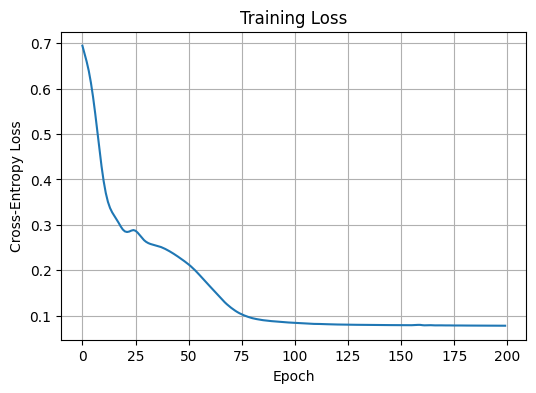

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

class MyReLU(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return torch.clamp(x, min=0)

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        return grad_output * (x > 0).float()


class MyLinear(nn.Module):

    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.1
        )

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

    def forward(self, x):
        return x @ self.weight.t() + self.bias


class MyAdam:

    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999),
        eps=1e-8
    ):

        self.params = list(params)

        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps

        self.state = {
            id(p): {
                "t": 0,
                "m": torch.zeros_like(p),
                "v": torch.zeros_like(p)
            }
            for p in self.params
        }

    @torch.no_grad()
    def step(self):

        for p in self.params:

            if p.grad is None:
                continue

            g = p.grad

            state = self.state[id(p)]

            state["t"] += 1
            t = state["t"]

            m = state["m"]
            v = state["v"]

            # Adam moments
            m.mul_(self.beta1).add_((1 - self.beta1) * g)
            v.mul_(self.beta2).add_((1 - self.beta2) * (g * g))

            # Bias correction
            m_hat = m / (1 - self.beta1 ** t)
            v_hat = v / (1 - self.beta2 ** t)

            # Parameter update
            p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

    def zero_grad(self):

        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()


def clip_grad_norm(params, max_norm):

    params = list(params)

    total_norm = 0.0

    for p in params:
        if p.grad is not None:
            total_norm += p.grad.pow(2).sum()

    total_norm = torch.sqrt(total_norm)

    if total_norm > max_norm:

        scale = max_norm / (total_norm + 1e-6)

        for p in params:
            if p.grad is not None:
                p.grad.mul_(scale)


X, y = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=0
)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

class Classifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = MyLinear(2, 32)
        self.fc2 = MyLinear(32, 32)
        self.fc3 = MyLinear(32, 2)

    def forward(self, x):

        x = MyReLU.apply(self.fc1(x))
        x = MyReLU.apply(self.fc2(x))
        x = self.fc3(x)

        return x


model = Classifier()

optimizer = MyAdam(
    model.parameters(),
    lr=1e-2
)


def grad_hook(module, grad_input, grad_output):

    grad = grad_output[0]

    print(
        f"{module.__class__.__name__} "
        f"grad norm = {grad.norm().item():.4f}"
    )

hook = model.fc2.register_full_backward_hook(grad_hook)

losses = []

for epoch in range(200):

    logits = model(X_train)

    loss = F.cross_entropy(logits, y_train)

    optimizer.zero_grad()

    loss.backward()

    # Gradient clipping
    clip_grad_norm(model.parameters(), max_norm=1.0)

    optimizer.step()

    losses.append(loss.item())

    if epoch % 20 == 0:

        with torch.no_grad():

            pred = model(X_test).argmax(dim=1)

            acc = (pred == y_test).float().mean()

        print(
            f"Epoch {epoch:3d} | "
            f"Loss {loss.item():.4f} | "
            f"Accuracy {acc.item():.4f}"
        )

hook.remove()


plt.figure(figsize=(6,4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

---
## Where to go next

If you finished the above:
- Re-do Exercise 7.4 (Adam) so that it supports **parameter groups** (different `lr` per group), like real `torch.optim` optimizers.
- Write a custom autograd function for **batch-norm** (forward + backward by hand) and compare against `nn.BatchNorm1d`.
- Read the source of `torch.optim.Adam` and `torch.nn.functional.cross_entropy` and compare them to your implementations.
- Look at `torch.func` (functorch) — `grad`, `vmap`, `jacrev` — and re-do the Hessian exercise in one line.